# AI System for Automatic Cognitive-Level Question Generation
## RAG + LLM + ModernBERT Bloom Taxonomy Classifier

This notebook implements the research pipeline described in **"AI System for Automatic Cognitive-Level Question Generation using Retrieval-Augmented Generation and Machine Learning Classification"**.

**Pipeline Architecture:**

| Phase | Component | Description |
|-------|-----------|-------------|
| **1A** | Knowledge Base | Load → preprocess → chunk → embed → store learning materials in Qdrant vector DB |
| **1B** | Classifier | Load pre-trained **ModernBERT** fine-tuned for Bloom's Taxonomy (C1–C6) |
| **2**  | RAG + LLM | Retrieve relevant context → generate questions with Llama-3.1-8B via Groq |
| **3**  | Evaluation + Feedback Loop | Classify generated question → compare with target → regenerate if non-ideal |

**Key updates from the original paper:**
- Classifier: SVM + TF-IDF → **pre-trained ModernBERT** (`manzarimalik/ModernBERT-Bloom-Taxonomy`)
- Language: Bahasa Indonesia → **English**
- Framework: built end-to-end with **LangChain**


---
## 1. Setup — Install Dependencies

Run this cell once per Colab session. It installs LangChain, Qdrant, Transformers, and Groq.

In [ ]:
# Run this once per Colab session
%pip install -q -U \
    langchain \
    langchain-core \
    langchain-community \
    langchain-groq \
    langchain-huggingface \
    langchain-qdrant \
    langchain-text-splitters \
    qdrant-client \
    sentence-transformers \
    transformers \
    accelerate \
    datasets

print("\n✅ Dependencies installed. Restart the runtime if Colab asks you to.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.1/114.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.7/588.7 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.3/234.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.

---
## 2. Imports

In [1]:
import os
import re
import json
from getpass import getpass
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# ── Transformers (Bloom classifier) ─────────────────────────────────
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    pipeline,
)

# ── LangChain core ───────────────────────────────────────────────────
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_text_splitters import RecursiveCharacterTextSplitter

# ── LangChain integrations ───────────────────────────────────────────
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_qdrant import QdrantVectorStore
from langchain_ollama import ChatOllama

# ── Qdrant (vector DB) ───────────────────────────────────────────────
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams

# ── Evaluation ───────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

print("✅ Imports OK")
print(f"   GPU available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU device    : {torch.cuda.get_device_name(0)}")

c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports OK
   GPU available : True
   GPU device    : NVIDIA GeForce RTX 3060


---
## 3. Configuration

Set API keys and model names. **You need a free Groq API key** — sign up at https://console.groq.com/keys.

In [2]:
# ── API KEYS ─────────────────────────────────────────────────────────
# Get a free key at: https://console.groq.com/keys
# if "GROQ_API_KEY" not in os.environ:
#     os.environ["GROQ_API_KEY"] = getpass("Enter your Groq API key: ")


# ── MODEL CONFIGURATION ──────────────────────────────────────────────
EMBEDDING_MODEL          = "sentence-transformers/all-MiniLM-L6-v2"
CLASSIFIER_MODEL         = "manzarimalik/ModernBERT-Bloom-Taxonomy"
CLASSIFIER_BASE_TOKENIZER = "answerdotai/ModernBERT-base"
LLM_MODEL                = "llama-3.1-8b-instant"   # via Groq — closest to Llama-3-8B

# ── VECTOR STORE ─────────────────────────────────────────────────────
COLLECTION_NAME = "learning_materials"
CHUNK_SIZE      = 500
CHUNK_OVERLAP   = 50
TOP_K           = 3   # number of retrieved chunks per query

# ── FEEDBACK LOOP ────────────────────────────────────────────────────
MAX_REGENERATION_ATTEMPTS = 3

# ── RATE LIMITING ────────────────────────────────────────────────────
# LLM_CALL_DELAY_SEC = 2.0   # jeda antar LLM call (detik). Naikkan kalau masih kena limit.

# ── BLOOM'S TAXONOMY MAPPING ─────────────────────────────────────────
# ModernBERT-Bloom-Taxonomy outputs label_0 … label_5 by default.
# If the model card already provides id2label, the pipeline will pick it up;
# this dict acts as a safe fallback / canonical mapping.
BLOOM_LABEL_MAP = {
    # Label format yang dipakai manzarimalik/ModernBERT-Bloom-Taxonomy
    "BT1": "Remember",
    "BT2": "Understand",
    "BT3": "Apply",
    "BT4": "Analyze",
    "BT5": "Evaluate",
    "BT6": "Create",
    # Fallback generic HuggingFace labels
    "LABEL_0": "Remember",
    "LABEL_1": "Understand",
    "LABEL_2": "Apply",
    "LABEL_3": "Analyze",
    "LABEL_4": "Evaluate",
    "LABEL_5": "Create",
}

BLOOM_TO_C = {
    "Remember":   "C1",
    "Understand": "C2",
    "Apply":      "C3",
    "Analyze":    "C4",
    "Evaluate":   "C5",
    "Create":     "C6",
}

BLOOM_ORDER = ["Remember", "Understand", "Apply", "Analyze", "Evaluate", "Create"]

print("✅ Configuration set")

✅ Configuration set


---
# 📚 PHASE 1A — Knowledge Base Construction

Steps:
1. Load learning-material documents
2. Preprocess + chunk into concept-sized units
3. Embed each chunk with a sentence-transformer
4. Store embeddings in an in-memory **Qdrant** vector database

### 3.1 Load Learning Materials

The dataset should contain at least four columns:
- `content`  — the actual paragraph / passage
- `topic`    — sub-topic name
- `subject`  — subject area (Biology, History, …)
- `keywords` — comma-separated keywords

Replace the sample data below with your own English-language CSV
(e.g. `pd.read_csv("materials.csv")`).

In [3]:
# ── Sample English learning materials (replace with your dataset) ────
# sample_materials = [
#     {
#         "content": (
#             "Photosynthesis is the biological process by which green plants, "
#             "algae, and certain bacteria convert light energy, usually from the sun, "
#             "into chemical energy stored in glucose. The process occurs primarily in "
#             "the chloroplasts of plant cells, where the green pigment chlorophyll "
#             "absorbs light. The overall chemical equation is "
#             "6CO2 + 6H2O + light → C6H12O6 + 6O2. Photosynthesis has two main stages: "
#             "the light-dependent reactions and the Calvin cycle (light-independent reactions)."
#         ),
#         "topic":    "Photosynthesis",
#         "subject":  "Biology",
#         "keywords": "photosynthesis, chlorophyll, chloroplast, glucose, Calvin cycle",
#     },
#     {
#         "content": (
#             "Newton's three laws of motion form the foundation of classical mechanics. "
#             "The first law (law of inertia) states that an object at rest stays at rest "
#             "and an object in motion stays in motion with the same speed and in the "
#             "same direction unless acted upon by an unbalanced force. The second law "
#             "is expressed as F = ma, where F is the net force, m is the mass, and a "
#             "is the acceleration. The third law states that for every action there is "
#             "an equal and opposite reaction."
#         ),
#         "topic":    "Newton's Laws of Motion",
#         "subject":  "Physics",
#         "keywords": "newton, force, motion, inertia, acceleration",
#     },
#     {
#         "content": (
#             "The French Revolution (1789–1799) was a period of radical political and "
#             "societal change in France that began with the Estates General of 1789 and "
#             "ended with the formation of the French Consulate in November 1799. Causes "
#             "included widespread economic hardship, an unfair tax system, and "
#             "Enlightenment ideas about liberty and equality. Key events include the "
#             "Storming of the Bastille on July 14, 1789, the Reign of Terror (1793–1794), "
#             "and the rise of Napoleon Bonaparte."
#         ),
#         "topic":    "French Revolution",
#         "subject":  "History",
#         "keywords": "french revolution, bastille, napoleon, enlightenment",
#     },
#     {
#         "content": (
#             "Object-oriented programming (OOP) is a programming paradigm based on the "
#             "concept of objects, which can contain data (attributes) and code "
#             "(methods). The four main pillars of OOP are encapsulation, inheritance, "
#             "polymorphism, and abstraction. Encapsulation bundles data and methods "
#             "together; inheritance allows a class to derive from a parent class; "
#             "polymorphism lets the same interface be used for different underlying "
#             "forms; abstraction hides complex implementation details behind simple "
#             "interfaces."
#         ),
#         "topic":    "Object-Oriented Programming",
#         "subject":  "Computer Science",
#         "keywords": "oop, encapsulation, inheritance, polymorphism, abstraction",
#     },
#     {
#         "content": (
#             "The water cycle, also known as the hydrologic cycle, describes the "
#             "continuous movement of water on, above, and below the surface of the Earth. "
#             "Its main processes are evaporation, condensation, precipitation, "
#             "infiltration, runoff, and transpiration. Solar energy drives the cycle by "
#             "evaporating water from oceans, lakes, and rivers. The vapor rises, cools, "
#             "and condenses into clouds, eventually falling back as precipitation."
#         ),
#         "topic":    "Water Cycle",
#         "subject":  "Earth Science",
#         "keywords": "water cycle, evaporation, condensation, precipitation",
#     },
# ]

# df_materials = pd.DataFrame(sample_materials)

# 👉 To use your own dataset, comment out the lines above and use:
df_materials = pd.read_csv("openstax_materials_v2_cleaned.csv")

print(f"Loaded {len(df_materials)} learning-material entries")
df_materials.head()

Loaded 350 learning-material entries


,content,topic,subject,keywords
0,Genetics is the study of heredity. Johann Greg...,Introduction to Patterns of Inheritance,Biology,"introduction chapter, chapter patterns, laws, ..."
1,"Today, members of this plant family are found ...",11.4 Speciation,Biology,"species, supercontinent gondwana, gondwana bro..."
2,"9.3 Transcription By the end of this section, ...",9.3 Transcription,Biology,"dna, learning objectives, dna template, transc..."
3,Another scenario in which populations might ex...,11.3 Evidence of Evolution,Biology,"population, founder effect, evolution, species..."
4,LINK T O LE ARNING Watch this Assignment Disco...,20.4 Aquatic and Marine Biomes,Biology,"wildlife refuge, national wildlife, arctic nat..."


### 3.2 Preprocess + Chunking

We wrap each row in a `Document` (preserving metadata) and split long passages
into concept-sized chunks using `RecursiveCharacterTextSplitter`.

In [4]:
def basic_clean(text: str) -> str:
    """Light cleaning for retrieval content — keep punctuation for context."""
    text = re.sub(r"\s+", " ", text)            # collapse whitespace
    text = re.sub(r"[^\x00-\x7F]+", " ", text)  # drop non-ASCII artifacts
    return text.strip()


# Build LangChain Documents
raw_documents: List[Document] = []
for _, row in df_materials.iterrows():
    raw_documents.append(
        Document(
            page_content=basic_clean(row["content"]),
            metadata={
                "topic":    row["topic"],
                "subject":  row["subject"],
                "keywords": row["keywords"],
            },
        )
    )

# Chunk
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", ". ", " ", ""],
)
chunks = text_splitter.split_documents(raw_documents)

print(f"Raw documents : {len(raw_documents)}")
print(f"Chunks created: {len(chunks)}")
print(f"\nExample chunk:\n  text: {chunks[0].page_content[:160]}...")
print(f"  meta: {chunks[0].metadata}")

Raw documents : 350
Chunks created: 3666

Example chunk:
  text: Genetics is the study of heredity. Johann Gregor Mendel set the framework for genetics long before chromosomes or genes had been identified, at a time when meio...
  meta: {'topic': 'Introduction to Patterns of Inheritance', 'subject': 'Biology', 'keywords': 'introduction chapter, chapter patterns, laws, mendel, gregor mendel'}


### 3.3 Embedding + Qdrant Vector Store

We use `all-MiniLM-L6-v2` (384-dim, fast, English) and store everything in an
**in-memory Qdrant** instance — no server needed.

In [5]:
# Embedding model
device = "cuda" if torch.cuda.is_available() else "cpu"
embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": device},
    encode_kwargs={"normalize_embeddings": True},
)

# Probe embedding dimension
embedding_dim = len(embeddings.embed_query("dimension probe"))
print(f"Embedding dim: {embedding_dim}")

# In-memory Qdrant client
qdrant_client = QdrantClient(":memory:")

# (Re-)create collection
if qdrant_client.collection_exists(COLLECTION_NAME):
    qdrant_client.delete_collection(COLLECTION_NAME)

qdrant_client.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=VectorParams(size=embedding_dim, distance=Distance.COSINE),
)

# Build the vector store
vectorstore = QdrantVectorStore(
    client=qdrant_client,
    collection_name=COLLECTION_NAME,
    embedding=embeddings,
)

# Ingest chunks
vectorstore.add_documents(chunks)
print(f"✅ Stored {len(chunks)} chunks in Qdrant collection '{COLLECTION_NAME}'")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 14756.06it/s]


Embedding dim: 384
✅ Stored 3666 chunks in Qdrant collection 'learning_materials'


---
# 🧠 PHASE 1B — Bloom Taxonomy Classifier (ModernBERT)

Load `manzarimalik/ModernBERT-Bloom-Taxonomy` with the **base** ModernBERT tokenizer (as in your snippet) and wrap it in a HuggingFace `text-classification` pipeline.

In [6]:
# Load tokenizer from BASE ModernBERT (not the fine-tuned one)
clf_tokenizer = AutoTokenizer.from_pretrained(CLASSIFIER_BASE_TOKENIZER)

# Load fine-tuned classifier
clf_model = AutoModelForSequenceClassification.from_pretrained(CLASSIFIER_MODEL)

bloom_pipe = pipeline(
    task="text-classification",
    model=clf_model,
    tokenizer=clf_tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    top_k=None,           # return scores for all classes
)

# Inspect labels the model actually emits
sample_out = bloom_pipe("What is the capital of Indonesia?")[0]
print("Raw classifier output:")
for item in sample_out:
    print(f"  {item['label']:<25} {item['score']:.4f}")

Loading weights: 100%|██████████| 174/174 [00:00<00:00, 14501.05it/s]


Raw classifier output:
  BT1                       0.9798
  BT2                       0.0083
  BT3                       0.0080
  BT4                       0.0033
  BT6                       0.0003
  BT5                       0.0002


### Helper — normalize classifier output to Bloom + C-code

In [7]:
def _normalize_label(raw_label: str) -> str:
    """Convert any label the model emits into a Bloom name (Remember…Create)."""
    # If the model already returns the proper name (e.g. "Remember"), keep it
    if raw_label in BLOOM_ORDER:
        return raw_label
    # Otherwise map LABEL_0 … LABEL_5
    return BLOOM_LABEL_MAP.get(raw_label, raw_label)


def classify_bloom(question: str) -> Dict:
    """Classify a single question; return top label, C-code, confidence, all scores."""
    raw = bloom_pipe(question)[0]              # list[dict] when top_k=None
    raw_sorted = sorted(raw, key=lambda x: x["score"], reverse=True)
    top = raw_sorted[0]
    bloom_name = _normalize_label(top["label"])
    return {
        "question":   question,
        "bloom":      bloom_name,
        "c_code":     BLOOM_TO_C.get(bloom_name, "?"),
        "confidence": float(top["score"]),
        "all_scores": {_normalize_label(r["label"]): float(r["score"]) for r in raw_sorted},
    }


# Quick smoke test
for q in [
    "What is the capital of Indonesia?",
    "Explain how photosynthesis converts light into chemical energy.",
    "Design an experiment to test Newton's third law in a frictionless environment.",
]:
    out = classify_bloom(q)
    print(f"[{out['c_code']} {out['bloom']:<11} conf={out['confidence']:.3f}]  {out['question']}")

[C1 Remember    conf=0.980]  What is the capital of Indonesia?
[C2 Understand  conf=0.743]  Explain how photosynthesis converts light into chemical energy.
[C6 Create      conf=0.650]  Design an experiment to test Newton's third law in a frictionless environment.


---
# ✍️ PHASE 2 — RAG-based Question Generation

We chain together:

1. **Retriever** → top-k semantically similar chunks from Qdrant
2. **Prompt** → instruct the LLM to generate questions at a target Bloom level
3. **LLM** → `llama-3.1-8b-instant` via Groq (free tier, very fast)
4. **Parser** → split the LLM output into individual questions

### 4.1 Retriever

In [8]:
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": TOP_K},
)

# Sanity check
demo_hits = retriever.invoke("photosynthesis stages")
for i, d in enumerate(demo_hits, 1):
    print(f"--- Hit {i} (subject={d.metadata['subject']}, topic={d.metadata['topic']}) ---")
    print(d.page_content[:180], "...\n")

--- Hit 1 (subject=Biology, topic=5.3 The Calvin Cycle) ---
. The Interworkings of the Calvin Cycle In plants, carbon dioxide (CO2) enters the leaf through the stomata and diffuses into the mesophyll cells and into the stroma of the chlorop ...

--- Hit 2 (subject=Biology, topic=13.2 Eukaryotic Origins) ---
. During the prokaryotic reign, photosynthetic prokaryotes evolved that were capable of applying the energy from sunlight to synthesize organic materials (like carbohydrates) from  ...

--- Hit 3 (subject=Biology, topic=5.3 The Calvin Cycle) ---
. 5.3 The Calvin Cycle By the end of this section, you will be able to: Describe the Calvin cycle Define carbon fixation Explain how photosynthesis works in the energy cycle of all ...



### 4.2 LLM (gemma3:4b)

In [9]:
llm = ChatOllama(
    model="mistral:7b",
    temperature=0.7,
    num_predict=200,         # ⬅ ganti nama dari max_tokens (Ollama pakai num_predict)
    num_ctx=4096,
    reasoning=False                        # context window — default 2048 kurang untuk RAG
)

# Sanity check
_test = llm.invoke("Say 'ready' in one word.")
print("LLM ready:", _test.content)

LLM ready:  Ready


### 4.3 Prompt Template

The prompt explicitly defines each Bloom level with action verbs, so the LLM
generates questions whose cognitive complexity matches the target.

In [10]:
QUESTION_GEN_PROMPT = ChatPromptTemplate.from_template("""\
You are an expert educational-assessment designer. Generate exam questions whose cognitive complexity matches a target level of Bloom's Taxonomy (Revised).

# Bloom's Taxonomy levels (use the listed action verbs)
- **C1 Remember**   — recall facts:        define, list, identify, name, recall, state
- **C2 Understand** — explain ideas:       describe, explain, summarize, classify, compare
- **C3 Apply**      — use in new context:  apply, demonstrate, solve, use, compute, illustrate
- **C4 Analyze**    — break apart ideas:   analyze, contrast, examine, differentiate, infer
- **C5 Evaluate**   — justify a decision:  assess, critique, judge, defend, justify, evaluate
- **C6 Create**     — produce new work:    design, construct, develop, formulate, propose, plan

# Retrieved learning-material context
{context}

# Task
Topic: **{topic}**
Target Bloom level: **{target_level}**
Number of questions: **{num_questions}**

# Rules
1. Each question MUST clearly target the {target_level} level (use its action verbs).
2. The question must be answerable from the context above (no hallucination).
3. Output one question per line. No numbering, no bullets, no commentary.
4. Do not write the answer — only the question.

# Question(s):
""")

### 4.4 Generation Chain (LCEL)

In [11]:
import time

def format_docs(docs: List[Document]) -> str:
    return "\n\n---\n\n".join(d.page_content for d in docs)


# Pure generation chain — given prepared inputs, produce text
generation_chain = QUESTION_GEN_PROMPT | llm | StrOutputParser()


def parse_questions(text: str) -> List[str]:
    """Split LLM output into individual question strings."""
    lines = [ln.strip(" -•\t") for ln in text.strip().splitlines()]
    # Drop empties + bullet artefacts; keep lines that end with a question mark
    qs = [ln for ln in lines if ln and ("?" in ln)]
    # Fallback: if no '?' found, return any non-empty lines
    return qs if qs else [ln for ln in lines if ln]


def generate_questions(
    topic: str,
    target_level: str,
    num_questions: int = 1,
    retrieval_query: Optional[str] = None,
) -> Tuple[List[str], List[Document]]:
    """Retrieve context for `topic`, then generate `num_questions` at `target_level`."""
    assert target_level in BLOOM_ORDER, f"target_level must be one of {BLOOM_ORDER}"

    query = retrieval_query or topic
    docs  = retriever.invoke(query)
    context = format_docs(docs)

    raw_text = generation_chain.invoke({
        "context":       context,
        "topic":         topic,
        "target_level":  target_level,
        "num_questions": num_questions,
    })

    # # ── Rate limit guard ────────────────────────────────────────────
    # time.sleep(LLM_CALL_DELAY_SEC)

    questions = parse_questions(raw_text)
    return questions, docs

### 4.5 Quick Test

In [12]:
qs, ctx_docs = generate_questions(
    topic="Photosynthesis",
    target_level="Analyze",
    num_questions=2,
)

print("Generated questions:")
for i, q in enumerate(qs, 1):
    print(f"  {i}. {q}")

Generated questions:
  1. 1. Compare and contrast the role of ATP in the light-dependent reactions of photosynthesis with its role as the primary energy currency for all cells.
  2. 2. Analyze the significance of molecular oxygen (O2) being a byproduct of the photosynthetic process that uses water as an electron donor, and how this process differs from other photosynthetic processes using different electron sources.


---
# 🔁 PHASE 3 — Evaluation + Feedback Loop

For each generated question we:
1. Run the ModernBERT classifier → predicted Bloom level.
2. Compare with the target level:
   - **Ideal**          — exact match  *(distance = 0)*
   - **Slightly Ideal** — adjacent level *(distance = 1)*
   - **Non-Ideal**      — distance ≥ 2  → regenerate
3. If non-ideal, send back to the LLM (up to `MAX_REGENERATION_ATTEMPTS`).


In [13]:
def evaluate_question(question: str, target_level: str) -> Dict:
    """Classify question + compare against target. Return status + metadata."""
    clf = classify_bloom(question)
    predicted = clf["bloom"]

    try:
        diff = abs(BLOOM_ORDER.index(predicted) - BLOOM_ORDER.index(target_level))
    except ValueError:
        diff = 99

    if diff == 0:
        status = "ideal"
    elif diff == 1:
        status = "slightly_ideal"
    else:
        status = "non_ideal"

    return {
        **clf,
        "target_level":      target_level,
        "level_difference":  diff,
        "status":            status,
    }


def generate_with_feedback(
    topic: str,
    target_level: str,
    max_attempts: int = MAX_REGENERATION_ATTEMPTS,
    accept_slightly_ideal: bool = True,
) -> Dict:
    """Generate → classify → regenerate until ideal/slightly-ideal or attempts exhausted."""
    history: List[Dict] = []
    accepted_statuses = {"ideal", "slightly_ideal"} if accept_slightly_ideal else {"ideal"}

    for attempt in range(1, max_attempts + 1):
        qs, _ = generate_questions(topic, target_level, num_questions=1)
        if not qs:
            history.append({"attempt": attempt, "question": None, "status": "generation_failed"})
            continue

        question = qs[0]
        eval_res = evaluate_question(question, target_level)
        eval_res["attempt"] = attempt
        history.append(eval_res)

        if eval_res["status"] in accepted_statuses:
            return {"final": eval_res, "history": history, "topic": topic}

    # Exhausted — return the closest attempt
    closest = min(
        (h for h in history if "level_difference" in h),
        key=lambda h: h["level_difference"],
        default=history[-1] if history else None,
    )
    return {"final": closest, "history": history, "topic": topic}

### Test the feedback loop

In [14]:
result = generate_with_feedback(
    topic="Newton's Laws of Motion",
    target_level="Create",
    max_attempts=3,
)

print(f"Topic         : {result['topic']}")
print(f"Final question: {result['final']['question']}")
print(f"Target → Pred : {result['final']['target_level']} → "
      f"{result['final']['bloom']}  ({result['final']['status']})")
print(f"Confidence    : {result['final']['confidence']:.3f}")
print(f"Attempts used : {len(result['history'])}")

print("\n--- Full history ---")
for h in result["history"]:
    print(f"  [attempt {h['attempt']}] {h.get('status', '—'):<14} "
          f"{h.get('bloom', '—'):<11} :: {h.get('question', '')[:90]}")

Topic         : Newton's Laws of Motion
Final question: 1. Design a scenario that demonstrates how Newton's first law of motion can be used to explain the behavior of an object on a frictionless surface, and propose two possible outcomes in situations where either a net external force is applied or not.
Target → Pred : Create → Create  (ideal)
Confidence    : 0.737
Attempts used : 1

--- Full history ---
  [attempt 1] ideal          Create      :: 1. Design a scenario that demonstrates how Newton's first law of motion can be used to exp


---
# 🚀 End-to-End Demo

Generate one question per Bloom level for a chosen topic and present the
results as a tidy DataFrame.

In [ ]:
def batch_generate(topic: str, levels: List[str] = None) -> pd.DataFrame:
    levels = levels or BLOOM_ORDER
    rows = []
    for lvl in levels:
        out = generate_with_feedback(topic, target_level=lvl, max_attempts=3)
        final = out["final"]
        rows.append({
            "topic":          topic,
            "target_level":   lvl,
            "target_c":       BLOOM_TO_C[lvl],
            "predicted":      final["bloom"],
            "predicted_c":    final["c_code"],
            "status":         final["status"],
            "confidence":     round(final["confidence"], 3),
            "attempts":       len(out["history"]),
            "question":       final["question"],
        })
    return pd.DataFrame(rows)


demo_df = batch_generate("Photosynthesis")
demo_df

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,topic,target_level,target_c,predicted,predicted_c,status,confidence,attempts,question
0,Photosynthesis,Remember,C1,Remember,C1,ideal,0.959,1,What is the overall chemical equation for phot...
1,Photosynthesis,Understand,C2,Remember,C1,slightly_ideal,0.512,1,Describe the primary location where photosynth...
2,Photosynthesis,Apply,C3,Apply,C3,ideal,0.741,1,What would be the effect on the overall chemic...
3,Photosynthesis,Analyze,C4,Analyze,C4,ideal,0.932,1,What are the key differences between the light...
4,Photosynthesis,Evaluate,C5,Evaluate,C5,ideal,0.998,2,Justify the importance of the light-independen...
5,Photosynthesis,Create,C6,Create,C6,ideal,0.868,1,Develop a model illustrating the relationship ...


---
# 📊 Classifier Evaluation on a Labeled Test Set

To report numbers for your paper (precision / recall / F1 / accuracy + confusion matrix),
benchmark the ModernBERT classifier on a labeled English Bloom-Taxonomy dataset.

Below we expect a CSV with two columns:
- `question` — the question text
- `label`    — one of `Remember, Understand, Apply, Analyze, Evaluate, Create`

Replace the sample with your own labeled file
(e.g. one obtained from SMA Muhammadiyah 9 Surabaya, translated into English,
or a public dataset such as `agentlans/educational-question-types-bloom`).


In [15]:
# Sample evaluation set (replace with your real CSV)
# sample_eval = [
#     ("List the products of photosynthesis.",                                   "Remember"),
#     ("Define Newton's first law of motion.",                                   "Remember"),
#     ("Explain how the Calvin cycle works.",                                    "Understand"),
#     ("Summarize the main causes of the French Revolution.",                    "Understand"),
#     ("Apply Newton's second law to calculate the acceleration of a 5 kg box pushed by 20 N.", "Apply"),
#     ("Use object-oriented principles to design a simple library system.",      "Apply"),
#     ("Analyze the differences between the light-dependent and light-independent reactions.", "Analyze"),
#     ("Compare the rise of Napoleon with the events of the Reign of Terror.",   "Analyze"),
#     ("Evaluate the ethical implications of the Reign of Terror.",              "Evaluate"),
#     ("Critique the effectiveness of OOP versus functional programming.",       "Evaluate"),
#     ("Design an experiment to measure the rate of photosynthesis under different light intensities.", "Create"),
#     ("Develop a new mnemonic to remember the four pillars of OOP.",            "Create"),
# ]
# df_eval = pd.DataFrame(sample_eval, columns=["question", "label"])

# 👉 Replace with your real test set:
df_eval = pd.read_csv("blooms_taxonomy_dataset.csv")

# ── Konversi dataframe agar match dengan format pipeline ─────────────

# 1. Rename kolom: 'Questions' → 'question', 'Category' → 'label'
df_eval = df_eval.rename(columns={
    "Questions": "question",
    "Category":  "label",
})

# 2. Mapping label BT1..BT6 → nama Bloom standar
BT_TO_BLOOM = {
    "BT1": "Remember",
    "BT2": "Understand",
    "BT3": "Apply",
    "BT4": "Analyze",
    "BT5": "Evaluate",
    "BT6": "Create",
}
df_eval["label"] = df_eval["label"].map(BT_TO_BLOOM)

# 3. Bersihkan: drop baris dengan label yang tidak ter-mapping (kalau ada label aneh di luar BT1-BT6)
before = len(df_eval)
df_eval = df_eval.dropna(subset=["label", "question"]).reset_index(drop=True)
after = len(df_eval)
if before != after:
    print(f"⚠️  Dropped {before - after} rows with unrecognized labels or empty questions")

# 4. Verifikasi hasil
print(f"Evaluation set size: {len(df_eval)}")
print(f"\nLabel distribution:")
print(df_eval["label"].value_counts().reindex(BLOOM_ORDER))
print(f"\nFirst 5 rows:")
df_eval.head()

Evaluation set size: 8767

Label distribution:
label
Remember      2582
Understand    1801
Apply         1508
Analyze       1293
Evaluate       783
Create         800
Name: count, dtype: int64

First 5 rows:


,question,label
0,About what proportion of the population of the...,Remember
1,Correctly label the brain lobes indicated on t...,Remember
2,Define compound interest.,Remember
3,Define four types of traceability,Remember
4,Define mercantilism.,Remember


In [ ]:
# Predict
preds = []
for q in df_eval["question"]:
    preds.append(classify_bloom(q)["bloom"])

df_eval["predicted"] = preds

# Metrics
y_true = df_eval["label"].tolist()
y_pred = df_eval["predicted"].tolist()

acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

print(f"Accuracy          : {acc:.4f}")
print(f"Precision (weighted): {prec:.4f}")
print(f"Recall    (weighted): {rec:.4f}")
print(f"F1-score  (weighted): {f1:.4f}")

print("\n--- Per-class report ---")
print(classification_report(y_true, y_pred, labels=BLOOM_ORDER, zero_division=0))

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Accuracy          : 0.8636
Precision (weighted): 0.8677
Recall    (weighted): 0.8636
F1-score  (weighted): 0.8629

--- Per-class report ---
              precision    recall  f1-score   support

    Remember       0.79      0.91      0.85      2582
  Understand       0.84      0.78      0.81      1801
       Apply       0.88      0.89      0.88      1508
     Analyze       0.91      0.74      0.82      1293
    Evaluate       0.96      0.96      0.96       783
      Create       0.98      0.97      0.97       800

    accuracy                           0.86      8767
   macro avg       0.89      0.87      0.88      8767
weighted avg       0.87      0.86      0.86      8767



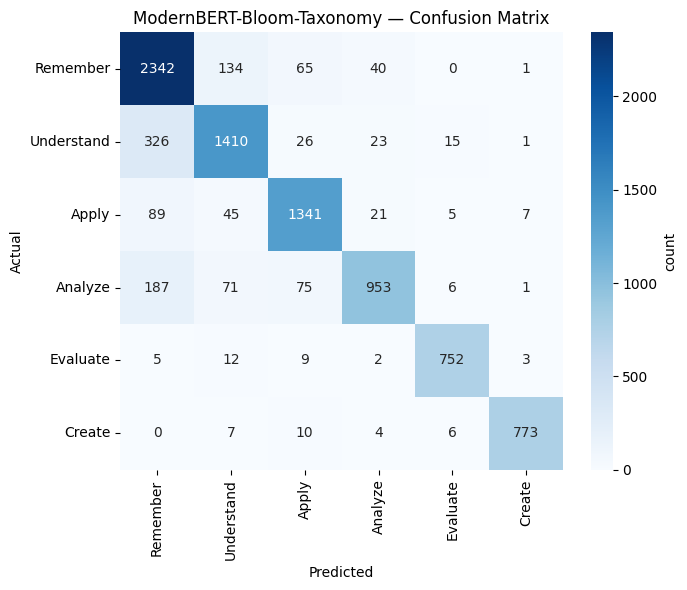

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=BLOOM_ORDER)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=BLOOM_ORDER, yticklabels=BLOOM_ORDER,
    cbar_kws={"label": "count"},
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ModernBERT-Bloom-Taxonomy — Confusion Matrix")
plt.tight_layout()
plt.show()

---
# 📐 Paper-Style Evaluation (Ideal / Slightly Ideal / Non-Ideal)

Replicate the **TP / FP / FN** definition introduced in Section 2.10 of the paper:

| Outcome | Distance | Meaning |
|---|---|---|
| TP — *Ideal*          | 0 | predicted level == target |
| FP — *Slightly Ideal* | 1 | adjacent Bloom level |
| FN — *Non-Ideal*      | ≥ 2 | far from target |

Run this on a batch of generated questions across all six levels.

In [16]:
# Checkpoint

import json
from pathlib import Path

CHECKPOINT_FILE = "mixtral_eval_checkpoint.jsonl"

def run_full_evaluation_resumable(topics, levels=BLOOM_ORDER):
    """Versi resumable: simpan progress ke disk setiap call selesai.
    Re-run notebook → otomatis lanjut dari yang belum selesai."""
    done = set()
    rows = []
    if Path(CHECKPOINT_FILE).exists():
        with open(CHECKPOINT_FILE, encoding="utf-8") as f:
            for line in f:
                r = json.loads(line)
                rows.append(r)
                done.add((r["topic"], r["target"]))
        print(f"✓ Resume dari checkpoint: {len(rows)} item sudah selesai")

    with open(CHECKPOINT_FILE, "a", encoding="utf-8") as f:
        for ti, topic in enumerate(topics, 1):
            for lvl in levels:
                if (topic, lvl) in done:
                    continue
                try:
                    out = generate_with_feedback(topic, target_level=lvl, max_attempts=2)
                    final = out["final"]
                    row = {
                        "topic":            topic,
                        "target":           lvl,
                        "predicted":        final["bloom"],
                        "level_difference": final["level_difference"],
                        "status":           final["status"],
                        "confidence":       final["confidence"],
                        "attempts":         len(out["history"]),
                        "question":         final["question"],
                    }
                except Exception as e:
                    print(f"⚠️  Error di ({topic[:40]}, {lvl}): {e}")
                    continue
                rows.append(row)
                f.write(json.dumps(row, ensure_ascii=False) + "\n")
                f.flush()  # ⬅ penting: pastikan ditulis langsung
            print(f"  [{ti}/{len(topics)}] {topic[:50]}")
    return pd.DataFrame(rows)

In [17]:
def run_full_evaluation(topics: List[str]) -> pd.DataFrame:
    rows = []
    for topic in topics:
        for lvl in BLOOM_ORDER:
        #   for _ in range(2):
            out = generate_with_feedback(topic, target_level=lvl, max_attempts=3)
            final = out["final"]
            rows.append({
                "topic":            topic,
                "target":           lvl,
                "predicted":        final["bloom"],
                "level_difference": final["level_difference"],
                "status":           final["status"],
                "confidence":       final["confidence"],
                "attempts":         len(out["history"]),
                "question":         final["question"],
            })
    return pd.DataFrame(rows)


# Run on all topics from the knowledge base
# all_topics = df_materials["topic"].tolist()
# eval_results = run_full_evaluation(all_topics)
# eval_results

all_topics = df_materials["topic"].drop_duplicates().tolist()
eval_results = run_full_evaluation_resumable(all_topics)
eval_results

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  [1/319] Introduction to Patterns of Inheritance
  [2/319] 11.4 Speciation
  [3/319] 9.3 Transcription
  [4/319] 11.3 Evidence of Evolution
  [5/319] 20.4 Aquatic and Marine Biomes
  [6/319] 13.4 Fungi
  [7/319] 4.3 Citric Acid Cycle and Oxidative Phosphorylatio
  [8/319] Introduction to Cell Structure and Function
  [9/319] Introduction to Reproduction at the Cellular Level
  [10/319] 3.4 The Cell Membrane
  [11/319] 15.5 Echinoderms and Chordates
  [12/319] Introduction to Diversity of Microbes, Fungi, and 
  [13/319] 15.6 Vertebrates
  [14/319] 7.2 Meiosis
  [15/319] Introduction to Molecular Biology
  [16/319] 7.3 Variations in Meiosis
  [17/319] 7.1 Sexual Reproduction
  [18/319] 9.5 How Genes Are Regulated
  [19/319] Introduction to Chemistry of Life
  [20/319] 15.4 Mollusks and Annelids
  [21/319] Introduction to Diversity of Animals
  [22/319] 15.3 Flatworms, Nematodes, and Arthropods
  [23/319] Measurements and the Metric System
  [24/319] 9.2 DNA Replication
  [25/319] 3.2 C

,topic,target,predicted,level_difference,status,confidence,attempts,question
0,Introduction to Patterns of Inheritance,Remember,Remember,0,ideal,0.558417,1,1. What is the basic functional unit of heredi...
1,Introduction to Patterns of Inheritance,Understand,Understand,0,ideal,0.952311,1,1. Explain how Mendel's law of segregation and...
2,Introduction to Patterns of Inheritance,Apply,Apply,0,ideal,0.952786,1,1. Use a Punnett square to calculate the expec...
3,Introduction to Patterns of Inheritance,Analyze,Analyze,0,ideal,0.551891,1,1. Compare and contrast Mendel's simple patter...
4,Introduction to Patterns of Inheritance,Evaluate,Understand,3,non_ideal,0.835806,2,1. Compare and contrast Mendel's simple patter...
...,...,...,...,...,...,...,...,...
1909,12.7 Prosocial Behavior,Understand,Understand,0,ideal,0.369456,1,3. What are some factors that attract people t...
1910,12.7 Prosocial Behavior,Apply,Apply,0,ideal,0.997512,1,1. How can you apply the triangular theory of ...
1911,12.7 Prosocial Behavior,Analyze,Understand,2,non_ideal,0.911161,2,1. Compare and contrast the triangular theory ...
1912,12.7 Prosocial Behavior,Evaluate,Evaluate,0,ideal,0.952600,1,1. Evaluate the justification for the claim th...


In [18]:
# Paper-style TP / FP / FN counts
tp = (eval_results["status"] == "ideal").sum()
fp = (eval_results["status"] == "slightly_ideal").sum()
fn = (eval_results["status"] == "non_ideal").sum()
total = len(eval_results)

precision_p = tp / (tp + fp) if (tp + fp) else 0.0
recall_p    = tp / (tp + fn) if (tp + fn) else 0.0
f1_p        = (2 * precision_p * recall_p / (precision_p + recall_p)
               if (precision_p + recall_p) else 0.0)
accuracy_p  = tp / total if total else 0.0

print("─" * 50)
print("PAPER-STYLE METRICS (Bloom-distance based) MIXTRAL")
print("─" * 50)
print(f"TP (Ideal)          : {tp}")
print(f"FP (Slightly Ideal) : {fp}")
print(f"FN (Non-Ideal)      : {fn}")
print(f"Total questions     : {total}")
print()
print(f"Precision : {precision_p:.4f}")
print(f"Recall    : {recall_p:.4f}")
print(f"F1-score  : {f1_p:.4f}")
print(f"Accuracy  : {accuracy_p:.4f}")

──────────────────────────────────────────────────
PAPER-STYLE METRICS (Bloom-distance based) MIXTRAL
──────────────────────────────────────────────────
TP (Ideal)          : 1367
FP (Slightly Ideal) : 377
FN (Non-Ideal)      : 170
Total questions     : 1914

Precision : 0.7838
Recall    : 0.8894
F1-score  : 0.8333
Accuracy  : 0.7142


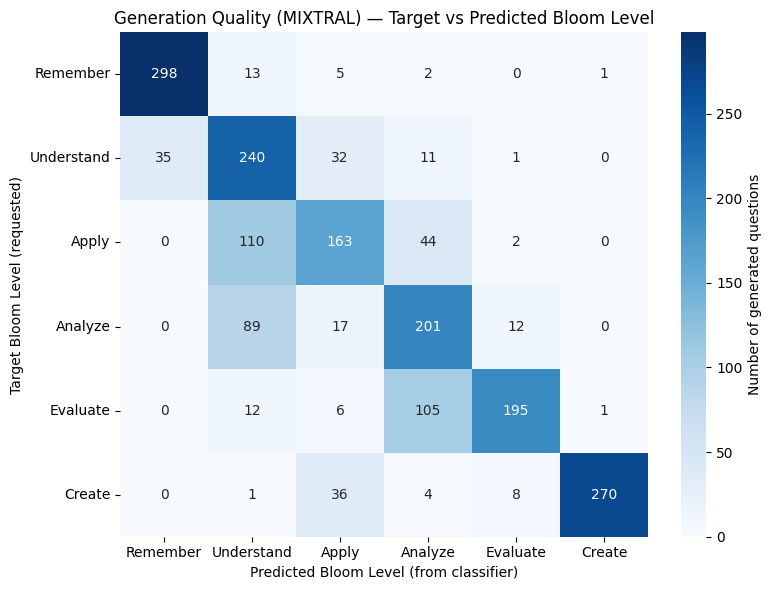

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from matplotlib.colors import ListedColormap

# ── Bangun confusion matrix: target (rows) vs predicted (cols) ────────
cm = confusion_matrix(
    eval_results["target"],
    eval_results["predicted"],
    labels=BLOOM_ORDER,
)

# ═════════════════════════════════════════════════════════════════════
# VARIASI 1: Confusion Matrix Klasik (count)
# ═════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=BLOOM_ORDER, yticklabels=BLOOM_ORDER,
    cbar_kws={"label": "Number of generated questions"},
    ax=ax,
)
ax.set_xlabel("Predicted Bloom Level (from classifier)")
ax.set_ylabel("Target Bloom Level (requested)")
ax.set_title("Generation Quality (MIXTRAL) — Target vs Predicted Bloom Level")
plt.tight_layout()
plt.show()

In [20]:
# Hitung TP/FP/FN per target level
per_level_stats = []
for lvl in BLOOM_ORDER:
    subset = eval_results[eval_results["target"] == lvl]
    tp_l = (subset["status"] == "ideal").sum()
    fp_l = (subset["status"] == "slightly_ideal").sum()
    fn_l = (subset["status"] == "non_ideal").sum()
    total_l = len(subset)

    precision_l = tp_l / (tp_l + fp_l) if (tp_l + fp_l) else 0.0
    recall_l    = tp_l / (tp_l + fn_l) if (tp_l + fn_l) else 0.0
    f1_l = (2 * precision_l * recall_l / (precision_l + recall_l)
            if (precision_l + recall_l) else 0.0)
    accuracy_l  = tp_l / total_l if total_l else 0.0

    per_level_stats.append({
        "Target Level": lvl,
        "Total":     total_l,
        "TP (Ideal)":     tp_l,
        "FP (Slightly)":  fp_l,
        "FN (Non-Ideal)": fn_l,
        "Precision":  round(precision_l, 4),
        "Recall":     round(recall_l, 4),
        "F1-score":   round(f1_l, 4),
        "Accuracy":   round(accuracy_l, 4),
    })

per_level_df = pd.DataFrame(per_level_stats)
print("PAPER-STYLE METRICS PER BLOOM LEVEL (MIXTRAL)")
print("=" * 80)
per_level_df

PAPER-STYLE METRICS PER BLOOM LEVEL (MIXTRAL)


,Target Level,Total,TP (Ideal),FP (Slightly),FN (Non-Ideal),Precision,Recall,F1-score,Accuracy
0,Remember,319,298,13,8,0.9582,0.9739,0.9660,0.9342
1,Understand,319,240,67,12,0.7818,0.9524,0.8587,0.7524
2,Apply,319,163,154,2,0.5142,0.9879,0.6763,0.5110
3,Analyze,319,201,29,89,0.8739,0.6931,0.7731,0.6301
4,Evaluate,319,195,106,18,0.6478,0.9155,0.7588,0.6113
5,Create,319,270,8,41,0.9712,0.8682,0.9168,0.8464


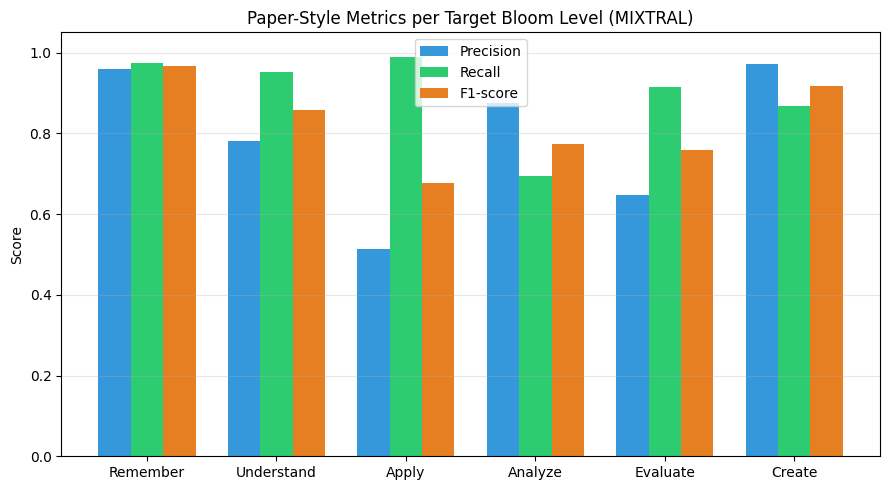

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(BLOOM_ORDER))
width = 0.25

ax.bar(x - width, per_level_df["Precision"], width, label="Precision", color="#3498db")
ax.bar(x,         per_level_df["Recall"],    width, label="Recall",    color="#2ecc71")
ax.bar(x + width, per_level_df["F1-score"],  width, label="F1-score",  color="#e67e22")

ax.set_xticks(x)
ax.set_xticklabels(BLOOM_ORDER)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Paper-Style Metrics per Target Bloom Level (MIXTRAL)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

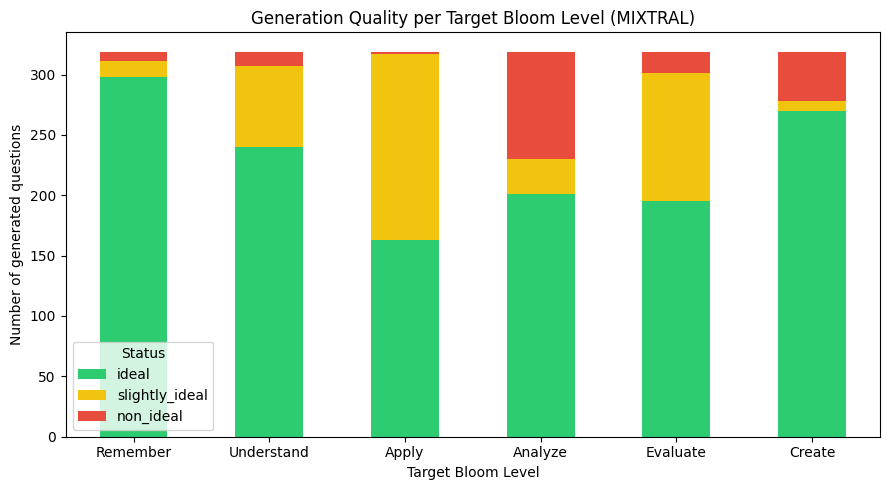

In [22]:
# Visualize status distribution per target level
status_counts = (
    eval_results
    .groupby(["target", "status"])
    .size()
    .unstack(fill_value=0)
    .reindex(BLOOM_ORDER)
)
# Ensure all three columns exist
for col in ["ideal", "slightly_ideal", "non_ideal"]:
    if col not in status_counts.columns:
        status_counts[col] = 0
status_counts = status_counts[["ideal", "slightly_ideal", "non_ideal"]]

status_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5),
    color=["#2ecc71", "#f1c40f", "#e74c3c"],
)
plt.title("Generation Quality per Target Bloom Level (MIXTRAL)")
plt.xlabel("Target Bloom Level")
plt.ylabel("Number of generated questions")
plt.xticks(rotation=0)
plt.legend(title="Status")
plt.tight_layout()
plt.show()

---
# 💾 Export Results

Persist evaluation outputs so you can include them in the paper.

In [23]:
eval_results.to_csv("MIXTRAL_evaluation_results.csv", index=False)
# demo_df.to_csv("demo_questions.csv", index=False)

print("✅ Saved: GEMMA_evaluation_results.csv, demo_questions.csv")
print("\nIn Colab → use the file panel on the left to download these CSVs.")

✅ Saved: GEMMA_evaluation_results.csv, demo_questions.csv

In Colab → use the file panel on the left to download these CSVs.


---
# 📝 How to Run This Notebook in Google Colab

1. **Upload** this `.ipynb` file to Google Colab (`File → Upload notebook`).
2. **Set runtime to GPU** (`Runtime → Change runtime type → T4 GPU`) — it will work on CPU, but ModernBERT inference is much faster on GPU.
3. **Get a Groq API key** (free) at <https://console.groq.com/keys> — Cell 3 will prompt for it.
4. **Run cells top-to-bottom**. The first install cell may ask you to restart the runtime; if so, restart and continue from the imports.
5. **Replace the sample data** in Sections 3.1 and the labeled test set with your real datasets (e.g. `pd.read_csv("/content/your_file.csv")` after uploading to Colab).
6. Results (CSVs) appear in the Colab file panel on the left — right-click → Download.

---

## 🔍 What each phase produces

| Phase | Output |
|---|---|
| 1A | A Qdrant vector store of chunked learning materials |
| 1B | A ModernBERT pipeline that maps any question → Bloom level + C-code |
| 2  | A LangChain LCEL chain: query → retrieve → generate questions |
| 3  | A feedback-loop function that regenerates non-ideal questions |
| Eval | Confusion matrix + paper-style TP/FP/FN/Precision/Recall/F1 |

## 🧩 Swappable components

- **LLM** → change `LLM_MODEL` to `llama-3.3-70b-versatile` (also via Groq) for stronger generation.
- **Embeddings** → swap `all-MiniLM-L6-v2` for `BAAI/bge-base-en-v1.5` for higher retrieval quality.
- **Classifier** → if you fine-tune your own ModernBERT, change `CLASSIFIER_MODEL` to its HF repo ID.
- **Vector DB** → swap `QdrantClient(":memory:")` for a persistent Qdrant URL.
